# Earnings Call Sentiment vs. Stock Price Movement
Angela Liou | Yu-Chien Chen

---
**Research Question:** Can earnings call sentiment predict abnormal stock returns in the days following the call?

###  Notebook Structure
| Section | Description |
|---|---|
| 0 | Install and import packages |
| 1 | Read PDF transcripts and automatically parse dates |
| 2 | Retrieve stock prices using yfinance and calculate CAR for the full event window|
| 3 | FinBERT sentiment analysis |
| 4 | Merge into the main dataset |
| 5 | Train models: Logistic Regression + XGBoost|
| 6 | Evaluate models: AUC, ROC, SHAP|
| 7 | Save files and create backups |

## Section 0: Read PDF transcripts and automatically parse dates

In [ ]:
!pip install pdfplumber yfinance transformers torch xgboost shap scikit-learn pandas numpy matplotlib -q
print('Done!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 125.3 MB/s eta 0:00:00
Done!


In [ ]:
import os, re, time, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import pdfplumber
import yfinance as yf

import torch
from transformers import pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
# 30 companies
TICKERS = {
    'Technology':  ['AAPL','MSFT','GOOGL','META','NVDA','AMZN','CRM','INTC'],
    'Financial':   ['JPM','BAC','GS','MS','BLK'],
    'Healthcare':  ['JNJ','UNH','PFE','ABT'],
    'Consumer':    ['WMT','COST','MCD','NKE','SBUX'],
    'Energy':      ['XOM','CVX','COP'],
    'Industrial':  ['CAT','BA','HON'],
    'Telecom':     ['VZ','T'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]
TICKER_TO_SECTOR = {t: s for s, tickers in TICKERS.items() for t in tickers}
print(f'Total companies: {len(ALL_TICKERS)}')

Total companies: 30


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PDF_FOLDER = '/content/drive/MyDrive/FA/Earnings/'

pdf_files = [f for f in os.listdir(PDF_FOLDER) if f.endswith('.pdf')]
print(f'Found {len(pdf_files)} PDF files:')
for f in sorted(pdf_files):
    print(f'  {f}')

Mounted at /content/drive
Found 300 PDF files:
  AAPL_2023_Q1.pdf
  AAPL_2023_Q2.pdf
  AAPL_2023_Q3.pdf
  AAPL_2023_Q4.pdf
  AAPL_2024_Q1.pdf
  AAPL_2024_Q2.pdf
  AAPL_2024_Q3.pdf
  AAPL_2024_Q4.pdf
  AAPL_2025_Q1.pdf
  AAPL_2025_Q2.pdf
  AAPL_2025_Q3.pdf
  AAPL_2025_Q4.pdf
  ABT_2023_Q1.pdf
  ABT_2023_Q2.pdf
  ABT_2023_Q3.pdf
  ABT_2023_Q4.pdf
  ABT_2024_Q1.pdf
  ABT_2024_Q2.pdf
  ABT_2024_Q3.pdf
  ABT_2024_Q4.pdf
  ABT_2025_Q1.pdf
  ABT_2025_Q2.pdf
  ABT_2025_Q3.pdf
  ABT_2025_Q4.pdf
  AMZN_2023_Q1.pdf
  AMZN_2023_Q2.pdf
  AMZN_2023_Q3.pdf
  AMZN_2023_Q4.pdf
  AMZN_2024_Q1.pdf
  AMZN_2024_Q2.pdf
  AMZN_2024_Q3.pdf
  AMZN_2024_Q4.pdf
  AMZN_2025_Q1.pdf
  AMZN_2025_Q2.pdf
  AMZN_2025_Q3.pdf
  AMZN_2025_Q4.pdf
  BAC_2023_Q1.pdf
  BAC_2023_Q2.pdf
  BAC_2023_Q3.pdf
  BAC_2023_Q4.pdf
  BAC_2024_Q1.pdf
  BAC_2024_Q2.pdf
  BAC_2024_Q3.pdf
  BAC_2024_Q4.pdf
  BAC_2025_Q1.pdf
  BAC_2025_Q2.pdf
  BAC_2025_Q3.pdf
  BAC_2025_Q4.pdf
  BA_Q1_2023.pdf
  BA_Q1_2024.pdf
  BA_Q1_2025.pdf
  BA_Q2_2023.p

In [ ]:
# mapping months and degits
MONTH_MAP = {
    'january':1,'february':2,'march':3,'april':4,
    'may':5,'june':6,'july':7,'august':8,
    'september':9,'october':10,'november':11,'december':12
}

def extract_date_from_text(text):

    text_lower = text.lower()

    # 1: Month DD, YYYY
    pattern1 = r'(january|february|march|april|may|june|july|august|september|october|november|december)\s+(\d{1,2}),?\s+(20\d{2})'
    match = re.search(pattern1, text_lower)
    if match:
        month = MONTH_MAP[match.group(1)]
        day   = int(match.group(2))
        year  = int(match.group(3))
        return f'{year}-{month:02d}-{day:02d}'

    # 2: YYYY-MM-DD
    pattern2 = r'(20\d{2})-(\d{2})-(\d{2})'
    match = re.search(pattern2, text)
    if match:
        return match.group(0)

    # 3: MM/DD/YYYY
    pattern3 = r'(\d{1,2})/(\d{1,2})/(20\d{2})'
    match = re.search(pattern3, text)
    if match:
        month = int(match.group(1))
        day   = int(match.group(2))
        year  = int(match.group(3))
        return f'{year}-{month:02d}-{day:02d}'

    return None


def extract_ticker_from_filename(filename):

    name = filename.replace('.pdf', '')
    parts = name.split('_')
    return parts[0].upper() if parts else None


def read_pdf(filepath):

    try:
        with pdfplumber.open(filepath) as pdf:
            pages = []
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    pages.append(text)
        full_text = '\n'.join(pages)
        full_text = re.sub(r'\s+', ' ', full_text).strip()
        return full_text
    except Exception as e:
        print(f'  Error reading PDF: {e}')
        return None


print(' PDF functions defined')

 PDF functions defined


In [ ]:
transcripts = []
skipped = []

for fname in sorted(pdf_files):
    fpath = os.path.join(PDF_FOLDER, fname)

    ticker = extract_ticker_from_filename(fname)
    if not ticker or ticker not in ALL_TICKERS:
        print(f'  Skipping {fname} — ticker "{ticker}" not in our list')
        skipped.append(fname)
        continue

    text = read_pdf(fpath)


    date = extract_date_from_text(text[:2000])

    transcripts.append({
        'ticker':   ticker,
        'date':     date,
        'filename': fname,
        'text':     text,
        'sector':   TICKER_TO_SECTOR.get(ticker, 'Unknown')
    })
    print(f' {fname} → {ticker} | {date} | {len(text):,} chars')

print(f'\n Successfully loaded: {len(transcripts)} transcripts')
if skipped:
    print(f'  Skipped: {skipped}')

 AAPL_2023_Q1.pdf → AAPL | 2023-02-02 | 46,651 chars
 AAPL_2023_Q2.pdf → AAPL | 2023-05-04 | 47,654 chars
 AAPL_2023_Q3.pdf → AAPL | 2023-08-03 | 47,935 chars
 AAPL_2023_Q4.pdf → AAPL | 2023-11-02 | 50,465 chars
 AAPL_2024_Q1.pdf → AAPL | 2024-02-01 | 45,990 chars
 AAPL_2024_Q2.pdf → AAPL | 2024-05-02 | 48,160 chars
 AAPL_2024_Q3.pdf → AAPL | 2024-08-01 | 47,319 chars
 AAPL_2024_Q4.pdf → AAPL | 2024-10-31 | 47,293 chars
 AAPL_2025_Q1.pdf → AAPL | 2025-01-30 | 47,018 chars
 AAPL_2025_Q2.pdf → AAPL | 2025-05-01 | 47,865 chars
 AAPL_2025_Q3.pdf → AAPL | 2025-07-31 | 47,968 chars
 AAPL_2025_Q4.pdf → AAPL | 2025-10-30 | 48,628 chars
 ABT_2023_Q1.pdf → ABT | 2023-04-19 | 50,027 chars
 ABT_2023_Q2.pdf → ABT | 2023-07-20 | 49,753 chars
 ABT_2023_Q3.pdf → ABT | 2023-10-18 | 48,410 chars
 ABT_2023_Q4.pdf → ABT | 2024-01-24 | 42,227 chars
 ABT_2024_Q1.pdf → ABT | 2024-04-17 | 48,876 chars
 ABT_2024_Q2.pdf → ABT | 2024-07-18 | 51,940 chars
 ABT_2024_Q3.pdf → ABT | 2024-10-16 | 50,090 chars
 ABT_20

In [ ]:
# date checking
df_check = pd.DataFrame([
    {'filename': t['filename'], 'ticker': t['ticker'], 'date': t['date'], 'text_preview': t['text'][:100]}
    for t in transcripts
])
print('Date extraction results:')
print(df_check[['filename','ticker','date']].to_string(index=False))

Date extraction results:
         filename ticker       date
 AAPL_2023_Q1.pdf   AAPL 2023-02-02
 AAPL_2023_Q2.pdf   AAPL 2023-05-04
 AAPL_2023_Q3.pdf   AAPL 2023-08-03
 AAPL_2023_Q4.pdf   AAPL 2023-11-02
 AAPL_2024_Q1.pdf   AAPL 2024-02-01
 AAPL_2024_Q2.pdf   AAPL 2024-05-02
 AAPL_2024_Q3.pdf   AAPL 2024-08-01
 AAPL_2024_Q4.pdf   AAPL 2024-10-31
 AAPL_2025_Q1.pdf   AAPL 2025-01-30
 AAPL_2025_Q2.pdf   AAPL 2025-05-01
 AAPL_2025_Q3.pdf   AAPL 2025-07-31
 AAPL_2025_Q4.pdf   AAPL 2025-10-30
  ABT_2023_Q1.pdf    ABT 2023-04-19
  ABT_2023_Q2.pdf    ABT 2023-07-20
  ABT_2023_Q3.pdf    ABT 2023-10-18
  ABT_2023_Q4.pdf    ABT 2024-01-24
  ABT_2024_Q1.pdf    ABT 2024-04-17
  ABT_2024_Q2.pdf    ABT 2024-07-18
  ABT_2024_Q3.pdf    ABT 2024-10-16
  ABT_2024_Q4.pdf    ABT 2025-01-22
  ABT_2025_Q1.pdf    ABT 2025-04-16
  ABT_2025_Q2.pdf    ABT 2025-07-17
  ABT_2025_Q3.pdf    ABT 2025-10-15
  ABT_2025_Q4.pdf    ABT 2026-01-22
 AMZN_2023_Q1.pdf   AMZN 2023-04-27
 AMZN_2023_Q2.pdf   AMZN 2023-08-03
 AM

## Parallel Analysis 1 : Main Target = CAR+5
Retrieve stock prices using yfinance and calculate CAR for the full event window，and use CAR+5 as Main Target

**Event Window Design：**

```
t-10  t-5        t=0       t+1   t+5  t+10
 |     |        [call]      |     |     |
 ←  Pre-event →        ←     Post-event       →
```

| Window | Purpose |
|---|---|
| t-10 ~ t-1 | Market expectations and background returns before the event|
| t=0 | Earnings call date |
| CAR+1 | Next-trading-day market reaction |
| CAR+3 | Early post-call market reaction|
| CAR+5 | Main prediction target for short-term post-call market reaction|
| CAR+10 | Robustness check for a longer post-event window |

### Calculate CAR

In [ ]:
def get_full_event_window(ticker, call_date_str):

    try:
        call_date = pd.Timestamp(call_date_str)

        # Download enough data before and after the event date
        start = call_date - timedelta(days=30)
        end = call_date + timedelta(days=25)

        # Download stock and market index data
        stock = yf.download(
            ticker,
            start=start,
            end=end,
            progress=False,
            auto_adjust=True
        )

        spy = yf.download(
            'SPY',
            start=start,
            end=end,
            progress=False,
            auto_adjust=True
        )

        if stock.empty or spy.empty:
            return None

        # Fix possible MultiIndex columns from yfinance
        if isinstance(stock.columns, pd.MultiIndex):
            stock.columns = stock.columns.get_level_values(0)

        if isinstance(spy.columns, pd.MultiIndex):
            spy.columns = spy.columns.get_level_values(0)

        # Align stock and SPY dates
        common_dates = stock.index.intersection(spy.index)
        stock = stock.loc[common_dates].copy()
        spy = spy.loc[common_dates].copy()

        if len(stock) == 0 or len(spy) == 0:
            return None

        # Find the trading day on or immediately after the earnings call date
        base_idx = stock.index.searchsorted(call_date)
        base_idx = min(base_idx, len(stock) - 1)

        base_stock_close = float(stock['Close'].iloc[base_idx])
        base_spy_close = float(spy['Close'].iloc[base_idx])
        actual_date = str(stock.index[base_idx].date())

        result = {
            'ticker': ticker,
            'call_date': call_date_str,
            'actual_date': actual_date
        }

        # Event-day abnormal return: open-to-close return on the event trading day
        stock_event_return = (
            float(stock['Close'].iloc[base_idx]) / float(stock['Open'].iloc[base_idx]) - 1
        )

        spy_event_return = (
            float(spy['Close'].iloc[base_idx]) / float(spy['Open'].iloc[base_idx]) - 1
        )

        result['CAR0'] = round(stock_event_return - spy_event_return, 6)

        # Post-event CAR windows
        # CAR+5 is the main short-term prediction target
        # CAR+10 is used as a robustness check
        for w in [1, 3, 5, 10]:
            if base_idx + w < len(stock):
                ret_stock = (
                    float(stock['Close'].iloc[base_idx + w]) / base_stock_close - 1
                )

                ret_spy = (
                    float(spy['Close'].iloc[base_idx + w]) / base_spy_close - 1
                )

                result[f'CAR+{w}'] = round(ret_stock - ret_spy, 6)
            else:
                result[f'CAR+{w}'] = None

        # Pre-event CAR windows
        # These capture market expectations and background returns before the call
        for w in [1, 5, 10]:
            pre_idx = base_idx - w

            if pre_idx >= 0:
                ret_stock = (
                    base_stock_close / float(stock['Close'].iloc[pre_idx]) - 1
                )

                ret_spy = (
                    base_spy_close / float(spy['Close'].iloc[pre_idx]) - 1
                )

                result[f'CAR-{w}'] = round(ret_stock - ret_spy, 6)
            else:
                result[f'CAR-{w}'] = None

        return result

    except Exception as e:
        print("  Error for {} on {}: {}".format(ticker, call_date_str, e))
        return None


print("CAR function defined.")

CAR function defined.


In [ ]:
sample = transcripts[0]
print(f'Testing: {sample["ticker"]} on {sample["date"]}')

result = get_full_event_window(sample['ticker'], sample['date'])
if result:
    print('\n✅ Result:')
    for k, v in result.items():
        if k not in ['ticker', 'call_date']:
            print(f'  {k}: {v}')
else:
    print(' Failed')

Testing: AAPL on 2023-02-02

✅ Result:
  actual_date: 2023-02-02
  CAR0: 0.008267
  CAR+1: 0.035029
  CAR+3: 0.029209
  CAR+5: 0.023581
  CAR+10: 0.041112
  CAR-1: 0.022505
  CAR-5: 0.01793
  CAR-10: 0.042549


In [ ]:
# Calculate the full event window CAR for all transcripts
print("Calculating CAR for {} transcripts...\n".format(len(transcripts)))

car_results = []

for i, t in enumerate(transcripts):
    result = get_full_event_window(t['ticker'], t['date'])

    if result:
        car_results.append(result)

        car_5 = result.get("CAR+5")
        car_10 = result.get("CAR+10")

        car_5_text = "{:.3%}".format(car_5) if car_5 is not None else "N/A"
        car_10_text = "{:.3%}".format(car_10) if car_10 is not None else "N/A"

        print("[{}/{}] {} {} | CAR+5={} | CAR+10={}".format(
            i + 1,
            len(transcripts),
            t["ticker"],
            t["date"],
            car_5_text,
            car_10_text
        ))

    else:
        print("[{}/{}] {} {} — skipped".format(
            i + 1,
            len(transcripts),
            t["ticker"],
            t["date"]
        ))

    # Avoid hitting the yfinance rate limit
    if (i + 1) % 10 == 0:
        time.sleep(2)

df_car = pd.DataFrame(car_results)

print("\nCAR calculated: {} rows".format(len(df_car)))
print(df_car.head())

Calculating CAR for 300 transcripts...

[1/300] AAPL 2023-02-02 | CAR+5=2.358% | CAR+10=4.111%
[2/300] AAPL 2023-05-04 | CAR+5=3.073% | CAR+10=2.251%
[3/300] AAPL 2023-08-03 | CAR+5=-6.252% | CAR+10=-6.062%
[4/300] AAPL 2023-11-02 | CAR+5=2.011% | CAR+10=2.458%
[5/300] AAPL 2024-02-01 | CAR+5=-1.083% | CAR+10=-4.099%
[6/300] AAPL 2024-05-02 | CAR+5=3.671% | CAR+10=5.179%
[7/300] AAPL 2024-08-01 | CAR+5=-0.036% | CAR+10=1.179%
[8/300] AAPL 2024-10-31 | CAR+5=-4.048% | CAR+10=-3.212%
[9/300] AAPL 2025-01-30 | CAR+5=-2.051% | CAR+10=0.995%
[10/300] AAPL 2025-05-01 | CAR+5=-8.601% | CAR+10=-6.475%
[11/300] AAPL 2025-07-31 | CAR+5=5.976% | CAR+10=10.236%
[12/300] AAPL 2025-10-30 | CAR+5=0.800% | CAR+10=1.815%
[13/300] ABT 2023-04-19 | CAR+5=-0.791% | CAR+10=1.006%
[14/300] ABT 2023-07-20 | CAR+5=0.665% | CAR+10=-3.097%
[15/300] ABT 2023-10-18 | CAR+5=0.860% | CAR+10=1.179%
[16/300] ABT 2024-01-24 | CAR+5=2.666% | CAR+10=-0.326%
[17/300] ABT 2024-04-17 | CAR+5=-0.036% | CAR+10=0.408%
[18/300

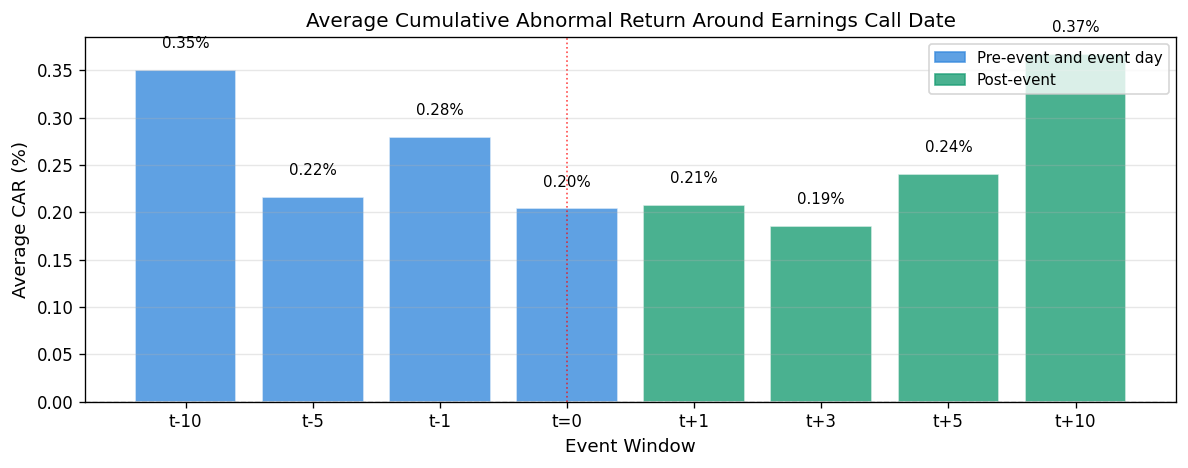

Plot saved!


In [ ]:
# Visualize the average CAR across the event window
windows = [
    'CAR-10',
    'CAR-5',
    'CAR-1',
    'CAR0',
    'CAR+1',
    'CAR+3',
    'CAR+5',
    'CAR+10'
]

labels = [
    't-10',
    't-5',
    't-1',
    't=0',
    't+1',
    't+3',
    't+5',
    't+10'
]

# Keep only columns that exist in df_car
available = [w for w in windows if w in df_car.columns]
avail_labels = [labels[windows.index(w)] for w in available]

means = df_car[available].mean()

fig, ax = plt.subplots(figsize=(10, 4))

colors = [
    '#378ADD' if 'CAR-' in w or w == 'CAR0' else '#1D9E75'
    for w in available
]

bars = ax.bar(
    avail_labels,
    means * 100,
    color=colors,
    alpha=0.8,
    edgecolor='white'
)

ax.axhline(
    0,
    color='gray',
    linewidth=0.8,
    linestyle='--'
)

if 't=0' in avail_labels:
    ax.axvline(
        avail_labels.index('t=0'),
        color='red',
        linewidth=1,
        linestyle=':',
        alpha=0.7
    )

ax.set_xlabel('Event Window', fontsize=11)
ax.set_ylabel('Average CAR (%)', fontsize=11)
ax.set_title('Average Cumulative Abnormal Return Around Earnings Call Date', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels above or below each bar
for bar, val in zip(bars, means * 100):
    if val >= 0:
        label_y = val + 0.02
        va = 'bottom'
    else:
        label_y = val - 0.02
        va = 'top'

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        "{:.2f}%".format(val),
        ha='center',
        va=va,
        fontsize=9
    )

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(color='#378ADD', alpha=0.8, label='Pre-event and event day'),
        Patch(color='#1D9E75', alpha=0.8, label='Post-event')
    ],
    fontsize=9
)

plt.tight_layout()
plt.savefig('/content/event_window_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

### FinBERT sentiment analysis

In [ ]:
print('Loading FinBERT...')
device = 0 if torch.cuda.is_available() else -1
print(f'Using: {"GPU " if device == 0 else "CPU (slower)"}')

finbert = pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    device=device,
    top_k=None
)
print('FinBERT loaded!')

Loading FinBERT...
Using: GPU 


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded!


In [ ]:
# Define word lists for uncertainty and risk-related language

UNCERTAINTY_WORDS = [
    'may', 'might', 'could', 'uncertain', 'uncertainty',
    'unclear', 'potential', 'possible', 'possibly',
    'approximately', 'estimate', 'estimated', 'subject to',
    'depend', 'depends', 'depending'
]

RISK_WORDS = [
    'risk', 'risks', 'concern', 'concerns',
    'challenging', 'challenge', 'challenges',
    'difficult', 'difficulty',
    'cautious', 'caution',
    'headwind', 'headwinds',
    'volatile', 'volatility',
    'pressure', 'pressures',
    'slowdown', 'softness', 'soft',
    'weakness', 'weaker',
    'inflation', 'recession',
    'supply chain', 'margin pressure',
    'cost pressure', 'decline', 'declined',
    'lower demand'
]

print("Sentiment word lists defined.")

Sentiment word lists defined.


In [ ]:
# Define a function to extract FinBERT sentiment and custom sentiment features

def analyze_sentiment(text, max_sentences=150):
    sentences = [
        s.strip()
        for s in re.split(r'[.!?]', str(text))
        if len(s.strip()) > 20
    ]

    sentences = sentences[:max_sentences]

    if not sentences:
        return None

    results = []

    for i in range(0, len(sentences), 16):
        batch = sentences[i:i + 16]

        try:
            batch_results = finbert(
                batch,
                truncation=True,
                max_length=512
            )

            results.extend(batch_results)

        except Exception as e:
            print("FinBERT batch skipped: {}".format(e))
            continue

    if not results:
        return None

    n = len(results)

    predicted_labels = [
        max(r, key=lambda x: x['score'])['label']
        for r in results
    ]

    pct_pos = predicted_labels.count('positive') / n
    pct_neg = predicted_labels.count('negative') / n
    pct_neu = predicted_labels.count('neutral') / n

    sentiment_score = pct_pos - pct_neg

    non_neutral_rate = pct_pos + pct_neg

    pos_to_neg_ratio = pct_pos / (pct_neg + 0.001)

    neutral_adjusted_score = (
        (pct_pos - pct_neg) / (pct_pos + pct_neg + 0.001)
    )

    sentiment_score_neg2 = pct_pos - 2 * pct_neg
    sentiment_score_neg3 = pct_pos - 3 * pct_neg

    text_lower = str(text).lower()
    word_count = len(str(text).split())

    if word_count == 0:
        uncertainty_rate = 0
        risk_language_rate = 0
    else:
        uncertainty_count = sum(
            text_lower.count(word)
            for word in UNCERTAINTY_WORDS
        )

        risk_count = sum(
            text_lower.count(word)
            for word in RISK_WORDS
        )

        uncertainty_rate = uncertainty_count / word_count * 1000
        risk_language_rate = risk_count / word_count * 1000

    return {
        'pct_positive': round(pct_pos, 4),
        'pct_negative': round(pct_neg, 4),
        'pct_neutral': round(pct_neu, 4),
        'sentiment_score': round(sentiment_score, 4),
        'non_neutral_rate': round(non_neutral_rate, 4),
        'pos_to_neg_ratio': round(pos_to_neg_ratio, 4),
        'neutral_adjusted_score': round(neutral_adjusted_score, 4),
        'sentiment_score_neg2': round(sentiment_score_neg2, 4),
        'sentiment_score_neg3': round(sentiment_score_neg3, 4),
        'uncertainty_rate': round(uncertainty_rate, 4),
        'risk_language_rate': round(risk_language_rate, 4),
        'word_count': word_count,
        'sentence_count': n
    }


print("Sentiment analysis function defined.")

Sentiment analysis function defined.


In [ ]:
# Run sentiment analysis for all transcripts

print("Analyzing {} transcripts...".format(len(transcripts)))

for i, t in enumerate(transcripts):
    features = analyze_sentiment(t['text'])

    if features:
        t.update(features)

        print("[{}/{}] {} {} | sentiment={:+.3f} | neutral_adj={:+.3f} | risk={:.3f}".format(
            i + 1,
            len(transcripts),
            t["ticker"],
            t["date"],
            features["sentiment_score"],
            features["neutral_adjusted_score"],
            features["risk_language_rate"]
        ))

    else:
        print("[{}/{}] {} {} | skipped".format(
            i + 1,
            len(transcripts),
            t["ticker"],
            t["date"]
        ))

print("\nSentiment analysis complete.")

Analyzing 300 transcripts...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[1/300] AAPL 2023-02-02 | sentiment=+0.260 | neutral_adj=+0.519 | risk=9.419
[2/300] AAPL 2023-05-04 | sentiment=+0.293 | neutral_adj=+0.563 | risk=5.456
[3/300] AAPL 2023-08-03 | sentiment=+0.340 | neutral_adj=+0.599 | risk=3.873
[4/300] AAPL 2023-11-02 | sentiment=+0.413 | neutral_adj=+0.703 | risk=3.799
[5/300] AAPL 2024-02-01 | sentiment=+0.407 | neutral_adj=+0.734 | risk=3.668
[6/300] AAPL 2024-05-02 | sentiment=+0.340 | neutral_adj=+0.585 | risk=3.849
[7/300] AAPL 2024-08-01 | sentiment=+0.380 | neutral_adj=+0.739 | risk=3.063
[8/300] AAPL 2024-10-31 | sentiment=+0.460 | neutral_adj=+0.872 | risk=1.600
[9/300] AAPL 2025-01-30 | sentiment=+0.467 | neutral_adj=+0.873 | risk=2.962
[10/300] AAPL 2025-05-01 | sentiment=+0.413 | neutral_adj=+0.859 | risk=4.132
[11/300] AAPL 2025-07-31 | sentiment=+0.413 | neutral_adj=+0.814 | risk=2.183
[12/300] AAPL 2025-10-30 | sentiment=+0.507 | neutral_adj=+0.925 | risk=2.913
[13/300] ABT 2023-04-19 | sentiment=+0.333 | neutral_adj=+0.693 | risk=4.

### Build master dataset

In [ ]:
# Build the master dataset by combining sentiment features with CAR features

SENTIMENT_FEATURES = [
    'pct_positive',
    'pct_negative',
    'pct_neutral',
    'sentiment_score',
    'non_neutral_rate',
    'pos_to_neg_ratio',
    'neutral_adjusted_score',
    'sentiment_score_neg2',
    'sentiment_score_neg3',
    'uncertainty_rate',
    'risk_language_rate',
    'word_count',
    'sentence_count'
]

df_sentiment = pd.DataFrame([
    {
        **{
            'ticker': t['ticker'],
            'date': t['date'],
            'sector': t['sector']
        },
        **{
            feature: t.get(feature)
            for feature in SENTIMENT_FEATURES
        }
    }
    for t in transcripts
    if all(t.get(feature) is not None for feature in SENTIMENT_FEATURES)
])

df_master = df_sentiment.merge(
    df_car,
    left_on=['ticker', 'date'],
    right_on=['ticker', 'call_date'],
    how='inner'
)

# Main target: CAR+5 > 0 means positive short-term post-call reaction
df_master['label'] = (df_master['CAR+5'] > 0).astype(int)

# Robustness target: CAR+10 > 0 means positive longer-window post-call reaction
df_master['label_10d'] = (df_master['CAR+10'] > 0).astype(int)

df_master.to_csv('/content/master_dataset.csv', index=False)

print("Master dataset: {} rows x {} columns".format(
    df_master.shape[0],
    df_master.shape[1]
))

print("Label distribution based on CAR+5:")
print(df_master['label'].value_counts().to_dict())

print("Robustness label distribution based on CAR+10:")
print(df_master['label_10d'].value_counts().to_dict())

print("Sector distribution:")
print(df_master['sector'].value_counts().to_dict())

df_master.head()

Master dataset: 300 rows x 28 columns
Label distribution based on CAR+5:
{1: 155, 0: 145}
Robustness label distribution based on CAR+10:
{1: 157, 0: 143}
Sector distribution:
{'Technology': 96, 'Financial': 60, 'Healthcare': 48, 'Industrial': 36, 'Energy': 24, 'Telecom': 24, 'Consumer': 12}


,ticker,date,sector,pct_positive,pct_negative,pct_neutral,sentiment_score,non_neutral_rate,pos_to_neg_ratio,neutral_adjusted_score,...,CAR0,CAR+1,CAR+3,CAR+5,CAR+10,CAR-1,CAR-5,CAR-10,label,label_10d
0,AAPL,2023-02-02,Technology,0.3800,0.1200,0.5000,0.2600,0.5000,3.1405,0.5190,...,0.008267,0.035029,0.029209,0.023581,0.041112,0.022505,0.017930,0.042549,1,1
1,AAPL,2023-05-04,Technology,0.4067,0.1133,0.4800,0.2933,0.5200,3.5569,0.5630,...,0.009881,0.028414,0.021753,0.030734,0.022511,-0.002831,0.002095,0.011228,1,1
2,AAPL,2023-08-03,Technology,0.4533,0.1133,0.4333,0.3400,0.5667,3.9650,0.5989,...,-0.003874,-0.043497,-0.059275,-0.062521,-0.060625,-0.004456,-0.002543,-0.002762,0,0
3,AAPL,2023-11-02,Technology,0.5000,0.0867,0.4133,0.4133,0.5867,5.7034,0.7033,...,0.001881,-0.014305,0.009611,0.020107,0.024576,0.001529,0.019854,0.001871,1,1
4,AAPL,2024-02-01,Technology,0.4800,0.0733,0.4467,0.4067,0.5533,6.4574,0.7336,...,0.006169,-0.015932,0.003287,-0.010829,-0.040985,0.000252,-0.040045,-0.036058,0,0


### Train models

In [ ]:
# Train classification models using sentiment, pre-event CAR, and sector features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

import xgboost as xgb

FEATURES_NUMERIC = [
    'pct_positive',
    'pct_negative',
    'pct_neutral',
    'sentiment_score',
    'non_neutral_rate',
    'pos_to_neg_ratio',
    'neutral_adjusted_score',
    'sentiment_score_neg2',
    'sentiment_score_neg3',
    'uncertainty_rate',
    'risk_language_rate',
    'CAR-1',
    'CAR-5',
    'CAR-10'
]

FEATURES_CATEGORICAL = [
    'sector'
]

model_df = df_master[
    FEATURES_NUMERIC + FEATURES_CATEGORICAL + ['label']
].dropna().copy()

X = model_df[FEATURES_NUMERIC + FEATURES_CATEGORICAL].copy()
X = pd.get_dummies(X, columns=FEATURES_CATEGORICAL, drop_first=True)

y = model_df['label']

print("Model dataset shape: {}".format(model_df.shape))
print("Feature matrix shape: {}".format(X.shape))
print("Label distribution:")
print(y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

print("\nTrain: {} | Test: {}".format(len(X_train), len(X_test)))
print("Baseline Accuracy: {:.4f}".format(baseline_accuracy))

# Scale features for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=500
)

lr_model.fit(X_train_scaled, y_train)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_lambda=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "XGBoost": (xgb_model, X_test),
    "Random Forest": (rf_model, X_test)
}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    print("\n{}".format(name))
    print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Balanced Accuracy: {:.4f}".format(balanced_accuracy_score(y_test, y_pred)))
    print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
    print("Recall: {:.4f}".format(recall_score(y_test, y_pred)))
    print("F1 Score: {:.4f}".format(f1_score(y_test, y_pred)))
    print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_proba)))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Model dataset shape: (300, 16)
Feature matrix shape: (300, 20)
Label distribution:
{1: 155, 0: 145}

Train: 240 | Test: 60
Baseline Accuracy: 0.5167

Logistic Regression
Accuracy: 0.4667
Balanced Accuracy: 0.4605
Precision: 0.4878
Recall: 0.6452
F1 Score: 0.5556
ROC-AUC: 0.4994

Confusion Matrix:
[[ 8 21]
 [11 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.28      0.33        29
           1       0.49      0.65      0.56        31

    accuracy                           0.47        60
   macro avg       0.45      0.46      0.44        60
weighted avg       0.46      0.47      0.45        60


XGBoost
Accuracy: 0.5167
Balanced Accuracy: 0.5156
Precision: 0.5312
Recall: 0.5484
F1 Score: 0.5397
ROC-AUC: 0.5217

Confusion Matrix:
[[14 15]
 [14 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.48      0.49        29
           1       0.53      0.55      0.54

### Model Evaluation

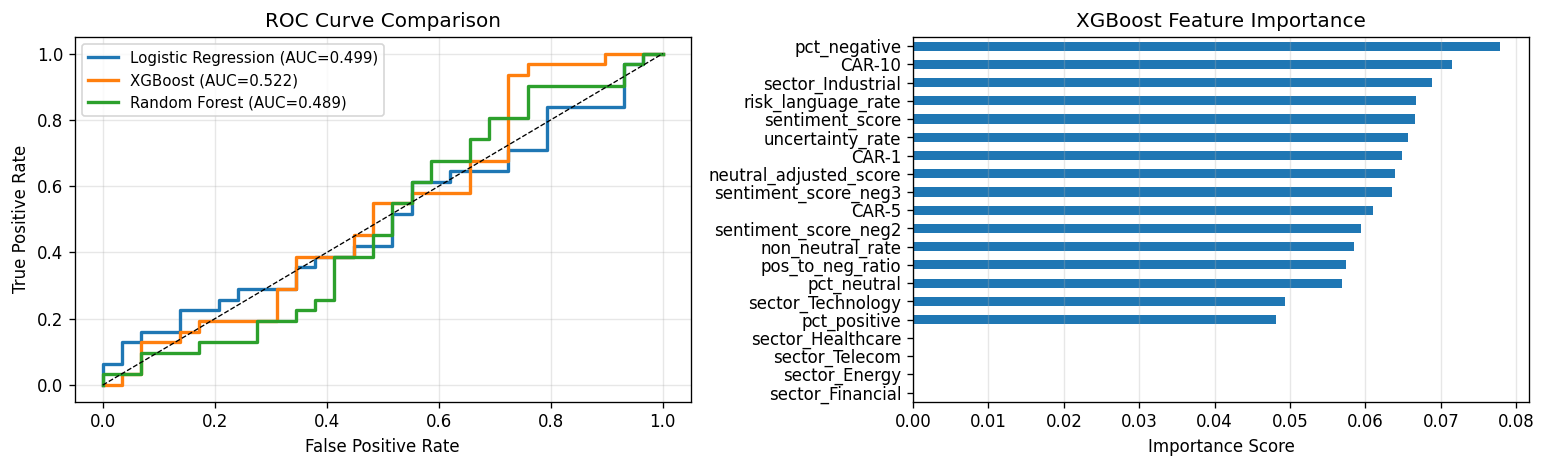

Model evaluation plot saved.


In [ ]:
# Visualize model performance and feature importance

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROC Curve
ax = axes[0]

model_probabilities = {
    "Logistic Regression": lr_proba,
    "XGBoost": xgb_proba,
    "Random Forest": rf_proba
}

for name, proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)

    ax.plot(
        fpr,
        tpr,
        label="{} (AUC={:.3f})".format(name, auc_score),
        linewidth=2
    )

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=0.8
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# XGBoost Feature Importance
ax = axes[1]

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values()

feature_importance.plot(
    kind='barh',
    ax=ax
)

ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Model evaluation plot saved.")

In [38]:
# Tune the classification threshold for XGBoost

thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

print("XGBoost threshold tuning:")

for threshold in thresholds:
    y_pred_threshold = (xgb_proba >= threshold).astype(int)

    print("\nThreshold: {:.2f}".format(threshold))
    print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_threshold)))
    print("Balanced Accuracy: {:.4f}".format(balanced_accuracy_score(y_test, y_pred_threshold)))
    print("Precision: {:.4f}".format(precision_score(y_test, y_pred_threshold)))
    print("Recall: {:.4f}".format(recall_score(y_test, y_pred_threshold)))
    print("F1 Score: {:.4f}".format(f1_score(y_test, y_pred_threshold)))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))

XGBoost threshold tuning:

Threshold: 0.35
Accuracy: 0.5167
Balanced Accuracy: 0.5000
Precision: 0.5167
Recall: 1.0000
F1 Score: 0.6813
Confusion Matrix:
[[ 0 29]
 [ 0 31]]

Threshold: 0.40
Accuracy: 0.5167
Balanced Accuracy: 0.5000
Precision: 0.5167
Recall: 1.0000
F1 Score: 0.6813
Confusion Matrix:
[[ 0 29]
 [ 0 31]]

Threshold: 0.45
Accuracy: 0.5500
Balanced Accuracy: 0.5345
Precision: 0.5345
Recall: 1.0000
F1 Score: 0.6966
Confusion Matrix:
[[ 2 27]
 [ 0 31]]

Threshold: 0.50
Accuracy: 0.5333
Balanced Accuracy: 0.5239
Precision: 0.5319
Recall: 0.8065
F1 Score: 0.6410
Confusion Matrix:
[[ 7 22]
 [ 6 25]]

Threshold: 0.55
Accuracy: 0.5833
Balanced Accuracy: 0.5857
Precision: 0.6154
Recall: 0.5161
F1 Score: 0.5614
Confusion Matrix:
[[19 10]
 [15 16]]

Threshold: 0.60
Accuracy: 0.4500
Balanced Accuracy: 0.4633
Precision: 0.3333
Recall: 0.0645
F1 Score: 0.1081
Confusion Matrix:
[[25  4]
 [29  2]]

Threshold: 0.65
Accuracy: 0.4833
Balanced Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Impact')
plt.tight_layout()
plt.savefig('/content/shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'FEATURES' is not defined

<Figure size 960x480 with 0 Axes>

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": (lr_model, scaler.transform(X_test)),
    "XGBoost": (xgb_model, X_test)
}

baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print("Baseline Accuracy: {:.4f}".format(baseline_accuracy))

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    print("\n{}".format(name))
    print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Balanced Accuracy: {:.4f}".format(balanced_accuracy_score(y_test, y_pred)))
    print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
    print("Recall: {:.4f}".format(recall_score(y_test, y_pred)))
    print("F1 Score: {:.4f}".format(f1_score(y_test, y_pred)))
    print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_proba)))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

### Save the file

In [ ]:
import shutil
from google.colab import files

os.makedirs('/content/models', exist_ok=True)

with open('/content/models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('/content/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('/content/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/content/models/features.json', 'w') as f:
    json.dump(FEATURES, f)

df_master.to_csv('/content/models/master_dataset.csv', index=False)

shutil.make_archive('/content/final_export', 'zip', '/content/models')
files.download('/content/final_export.zip')

print('Files saved:')
for f in os.listdir('/content/models'):
    size = os.path.getsize(f'/content/models/{f}')
    print(f'  {f} ({size/1024:.1f} KB)')
print('\n🎉 Notebook complete! Next: build Streamlit app.')

NameError: name 'FEATURES' is not defined

# New Section